In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:

import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


## Lectura de fichero y adaptación de los tipos


In [4]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  semana              625800 non-null  int64         
 12  lag_ventas_1        625800 non-null  fl

# LightGBM

El algoritmo **LightGBM** (Light Gradient Boosting Machine) es una implementación altamente eficiente de los **Gradient Boosting Decision Trees (GBDT)**, un potente método de **aprendizaje de conjunto (*ensemble*)** que utiliza una estrategia de **Boosting**.

A diferencia de Random Forest, que utiliza *bagging* (entrenamiento en paralelo de árboles descorrelacionados) [Previous response], LightGBM construye sus modelos de forma **secuencial** para optimizar la predicción.

**Bases de LightGBM (GBDT)**

1.  **Mecanismo de Conjunto (Boosting Secuencial):**
    *   **Aprendizaje Aditivo:** LightGBM entrena una serie de **aprendices débiles** (generalmente árboles de decisión) de forma secuencial, donde cada nuevo árbol intenta **corregir los errores** de la suma acumulada de los árboles anteriores.
    *   **Optimización por Gradiente:** El proceso de construcción de árboles está dirigido por la **minimización del gradiente** de la función de pérdida. Específicamente, los árboles se ajustan a los **pseudo-residuales** (el gradiente negativo de la función de pérdida) de la iteración anterior.
    *   **Predicción Final:** La predicción se obtiene mediante una **suma ponderada** de las salidas de todos los árboles en el *ensemble*.

2.  **Eficiencia y Escalabilidad (Innovación):**
    *   LightGBM se destaca por su **velocidad y rendimiento superior**, logrando una **drástica reducción en el tiempo de entrenamiento** en comparación con otras implementaciones de GBDT.
    *   **Paralelización:** A pesar de la naturaleza secuencial del *boosting*, LightGBM emplea **múltiples estrategias de paralelización** (incluyendo paralelización por características, por datos y por votación) para acelerar el cálculo.

3.  **Robustez y Manejo de Datos:**
    *   **Manejo de Datos Categóricos:** LightGBM tiene un soporte nativo para características categóricas. Determina el *split* óptimo ordenando los valores categóricos en función de las **estadísticas objetivo promedio** (*average target statistics*).
    *   **Imputación y Normalización:** El algoritmo está diseñado para **manejar valores faltantes de forma nativa**. Además, **no es sensible a la normalización de los datos**.
    *   **Regularización:** Dado que los algoritmos de *boosting* son propensos al sobreajuste (alta varianza), LightGBM incorpora técnicas de **regularización** explícitas (como la **tasa de aprendizaje/shrinkage**) y regularización **L1 y L2** directamente en el objetivo para controlar la complejidad del modelo.

LightGBM es un modelo de **alta precisión** que utiliza un enfoque de **regresión de árbol basado en gradiente** y es una opción sólida para la regresión y el pronóstico, especialmente en escenarios donde la velocidad y el manejo eficiente de grandes conjuntos de datos son cruciales.

# Preparación de datos

In [5]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [6]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'trimestre',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE LIGHTGBM")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE LIGHTGBM


# LightGBM global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de LightGBM para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:
# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (LightGBM)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: LIGHTGBM GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")




🔍 MODELO 1: LIGHTGBM GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:

print("\n🔎 Búsqueda de hiperparámetros con Optuna para LightGBM...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA LIGHTGBM
# =====================================================

def objective_lgb(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt','dart']),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', -1, 12),  # -1 significa sin límite
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    model = lgb.LGBMRegressor(**params, random_state=42)

    # Entrenar con early stopping
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(50)])
    
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse


# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para LightGBM...")
start_time = time.perf_counter()

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=5, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros LightGBM:")
print(study_lgb.best_params)


[I 2025-12-01 15:42:45,300] A new study created in memory with name: no-name-549ff0ad-b4eb-43ad-ae41-d237ab466493



🔎 Búsqueda de hiperparámetros con Optuna para LightGBM...

🔍 Iniciando optimización de hiperparámetros con Optuna para LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[629]	valid_0's rmse: 1.96815


[I 2025-12-01 15:43:05,502] Trial 0 finished with value: 3.8736324059857226 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 24, 'n_estimators': 1029, 'learning_rate': 0.01429647867939776, 'max_depth': 6, 'min_child_samples': 24, 'bagging_fraction': 0.7510250116253548, 'bagging_freq': 4, 'feature_fraction': 0.9277405167083069, 'reg_lambda': 1.6009118259631925, 'reg_alpha': 2.9221386977711026, 'min_split_gain': 0.8479829893340667}. Best is trial 0 with value: 3.8736324059857226.
[I 2025-12-01 15:43:49,846] Trial 1 finished with value: 3.9763759776561756 and parameters: {'boosting_type': 'dart', 'num_leaves': 55, 'n_estimators': 701, 'learning_rate': 0.032318339809318024, 'max_depth': 1, 'min_child_samples': 16, 'bagging_fraction': 0.7980209550950303, 'bagging_freq': 5, 'feature_fraction': 0.8773555922578462, 'reg_lambda': 1.9118187976122005, 'reg_alpha': 2.7039927247230664, 'min_split_gain': 0.9670892111216947}. Best is trial 0 with value: 3.8736324059857226.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[324]	valid_0's rmse: 1.96795


[I 2025-12-01 15:43:59,504] Trial 2 finished with value: 3.872809319548414 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 95, 'n_estimators': 819, 'learning_rate': 0.031237853467975682, 'max_depth': 5, 'min_child_samples': 14, 'bagging_fraction': 0.7611056309760459, 'bagging_freq': 6, 'feature_fraction': 0.7227721730308039, 'reg_lambda': 0.8679782285455794, 'reg_alpha': 1.0033702328075753, 'min_split_gain': 0.8135941017327032}. Best is trial 2 with value: 3.872809319548414.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[296]	valid_0's rmse: 1.96457


[I 2025-12-01 15:44:07,999] Trial 3 finished with value: 3.8595518309118018 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 103, 'n_estimators': 1120, 'learning_rate': 0.043779885464958895, 'max_depth': 0, 'min_child_samples': 11, 'bagging_fraction': 0.8591060327989213, 'bagging_freq': 1, 'feature_fraction': 0.7771842838877645, 'reg_lambda': 2.5479239490489336, 'reg_alpha': 2.689599766944751, 'min_split_gain': 0.43944507020172807}. Best is trial 3 with value: 3.8595518309118018.
[I 2025-12-01 15:49:37,188] Trial 4 finished with value: 3.8662168870761615 and parameters: {'boosting_type': 'dart', 'num_leaves': 125, 'n_estimators': 772, 'learning_rate': 0.07384597004185892, 'max_depth': 11, 'min_child_samples': 76, 'bagging_fraction': 0.8652733902079499, 'bagging_freq': 4, 'feature_fraction': 0.9873493456435053, 'reg_lambda': 2.8916282647885385, 'reg_alpha': 1.240916027153692, 'min_split_gain': 0.19383008567245164}. Best is trial 3 with value: 3.8595518309118018.


✅ Optuna completado en 411.89 segundos

🏆 Mejores hiperparámetros LightGBM:
{'boosting_type': 'gbdt', 'num_leaves': 103, 'n_estimators': 1120, 'learning_rate': 0.043779885464958895, 'max_depth': 0, 'min_child_samples': 11, 'bagging_fraction': 0.8591060327989213, 'bagging_freq': 1, 'feature_fraction': 0.7771842838877645, 'reg_lambda': 2.5479239490489336, 'reg_alpha': 2.689599766944751, 'min_split_gain': 0.43944507020172807}


In [9]:
print("\nEntrenando modelo LIGTHgbm con mejores hiperparámetros en todo el conjunto de entrenamiento...")
best_lgb = lgb.LGBMRegressor(
    **study_lgb.best_params,
    random_state=42,
    n_jobs=-1)

best_lgb.fit(X_train, y_train)



Entrenando modelo LIGTHgbm con mejores hiperparámetros en todo el conjunto de entrenamiento...


,boosting_type,'gbdt'
,num_leaves,103
,max_depth,0
,learning_rate,0.043779885464958895
,n_estimators,1120
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.43944507020172807
,min_child_weight,0.001
,min_child_samples,11


In [10]:
from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_lgb.predict(X_test)

# Calcular métricas
metricas_test_global = calcular_metricas(y_test, y_test_pred, 'LightGBM Global')

# todas_metricas.append(metricas_train_global)
todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(y_test_cl, y_test_pred_cl, f'LightGBM Global Cluster {cluster}')
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(y_test_prod, y_test_pred_prod, f'LightGBM Global Cluster {cluster} Producto {producto}')
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)    



📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
     LightGBM Global 1.5698 5.7123  2.39 0.2546     49.83     144.62 0.7324    96.14

🏆 Mejor modelo: LightGBM Global (RMSE: 2.3900)

📊 RESUMEN DE MÉTRICAS
                             Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Global Cluster 3 Producto 314 0.1936   0.0637  0.2523  0.0000       NaN     200.00    NaN      NaN
LightGBM Global Cluster 3 Producto 257 0.7872   1.3285  1.1526 -0.0012     76.26     185.97 0.7843   157.44
             LightGBM Global Cluster 3 1.0734   2.7514  1.6587  0.0781     55.17     168.90 0.7443   132.17
LightGBM Global Cluster 0 Producto 413 1.7489   4.7086  2.1699  0.0272     35.48     102.78 0.7596    84.21
                       LightGBM Global 1.5698   5.7123  2.3900  0.2546     49.83     144.62 0.7324    96.14
             LightGBM Global Cluster 0 1.8023   6.6280  2

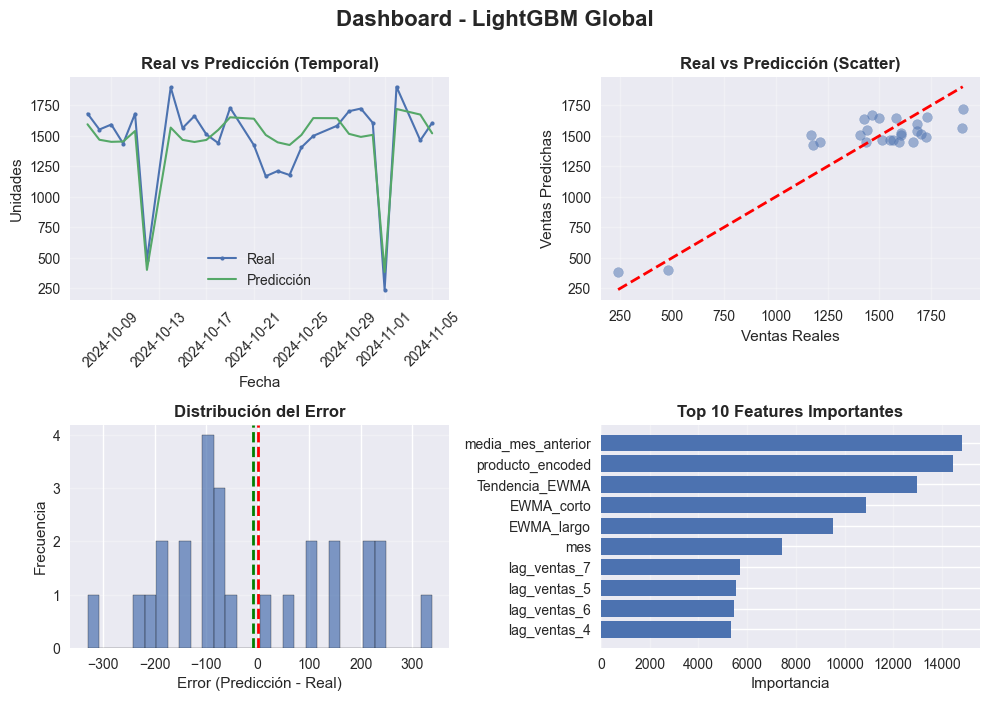

In [11]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_lgb,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - LightGBM Global',
        figsize=(10, 7)
        )

# LightGBM por Cluster


📍 MODELO 2: LightGBM POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  LightGBM Cluster 0 1.8199 6.9573 2.6377 0.0548     40.56     126.35 0.7582    94.25

🏆 Mejor modelo: LightGBM Cluster 0 (RMSE: 2.6377)


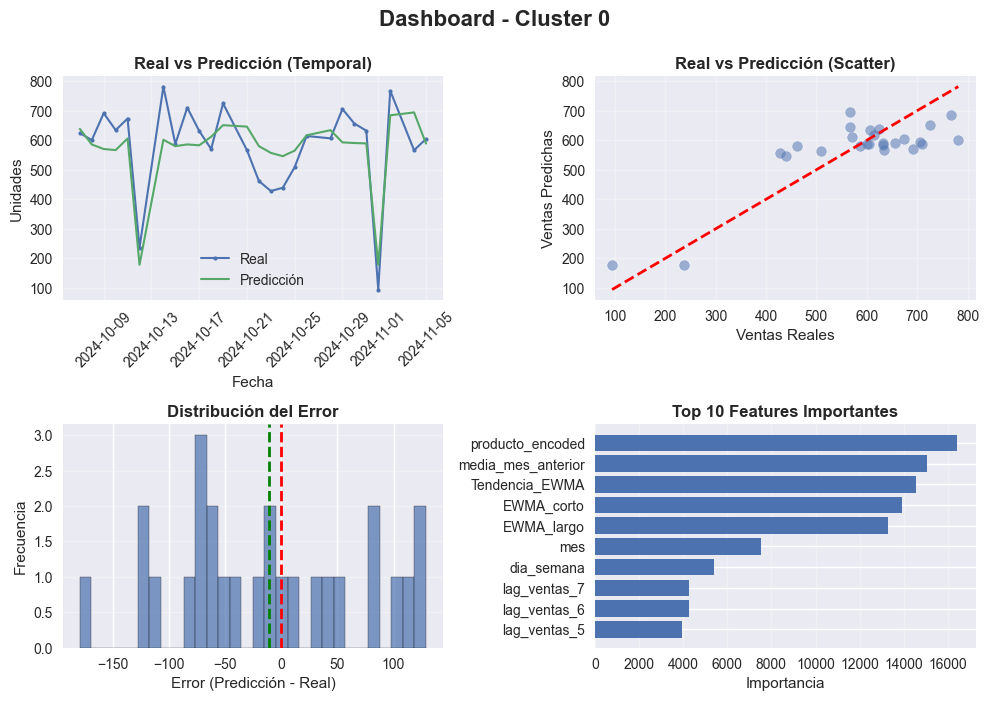


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  LightGBM Cluster 1 2.8206 13.361 3.6553 0.1113     56.72      99.34 0.7306    73.97

🏆 Mejor modelo: LightGBM Cluster 1 (RMSE: 3.6553)


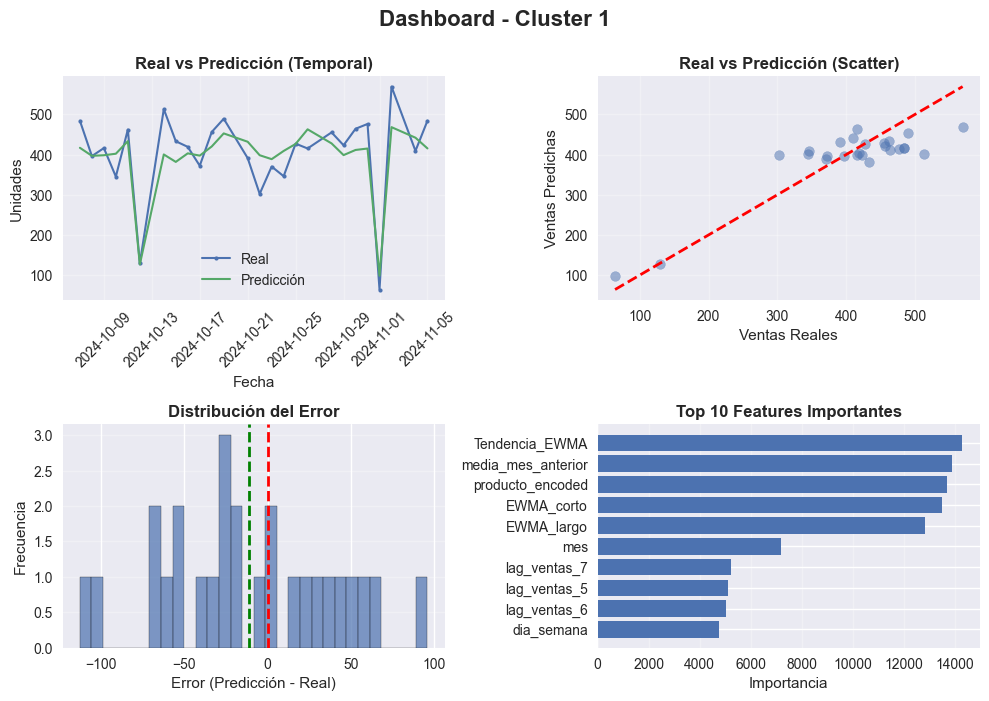


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  LightGBM Cluster 2 3.8146 27.0806 5.2039 0.1631     78.86      83.12 0.7237    66.42

🏆 Mejor modelo: LightGBM Cluster 2 (RMSE: 5.2039)


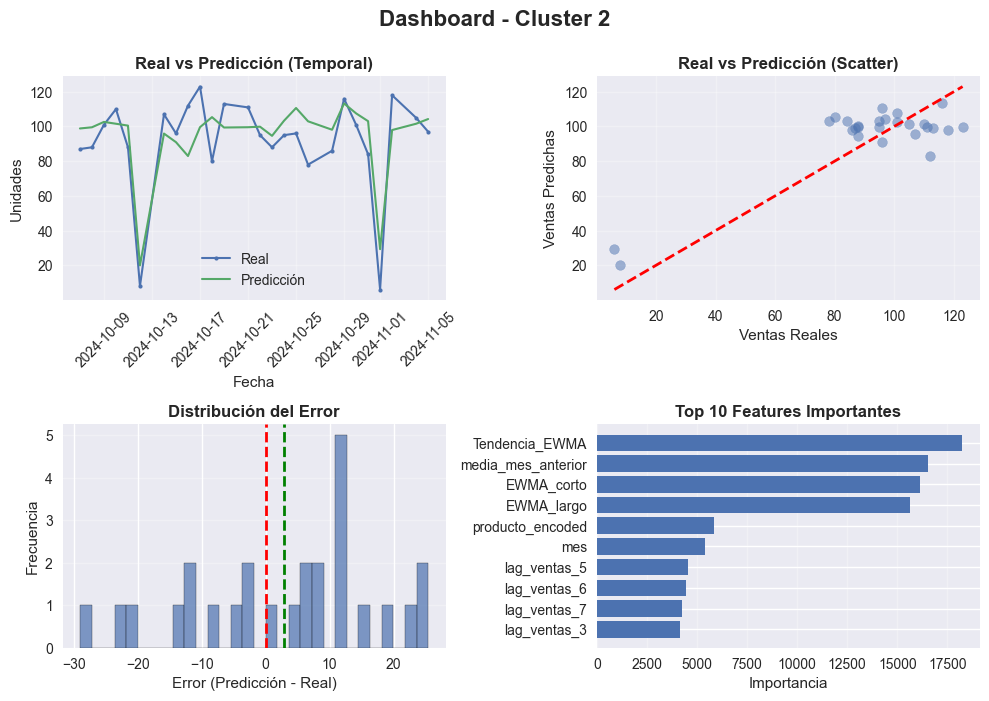


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  LightGBM Cluster 3 1.0748 2.7969 1.6724 0.0628     56.87     169.66 0.7505   132.34

🏆 Mejor modelo: LightGBM Cluster 3 (RMSE: 1.6724)


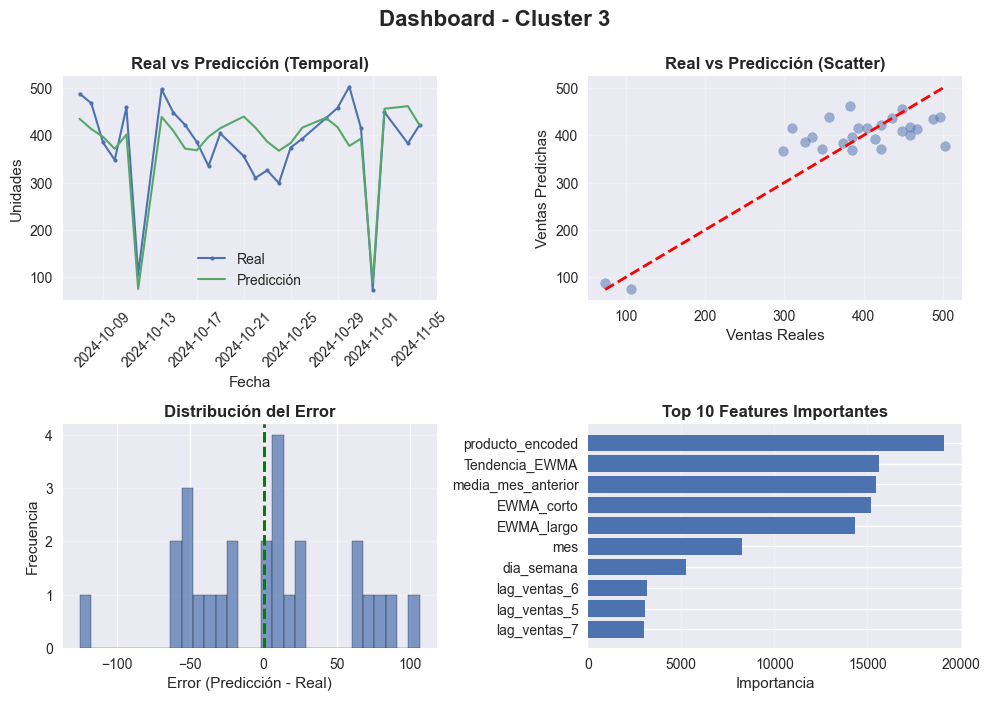

In [12]:
# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 2: LightGBM POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
    
    # Entrenar
    lgb_cluster = lgb.LGBMRegressor(
        **study_lgb.best_params,
        random_state=42,
        n_jobs=-1)
    
    lgb_cluster.fit(X_train_c, y_train_c)
    y_pred_c = lgb_cluster.predict(X_test_c)
    
    # modelos_cluster[cluster] = rf_cluster
    
    # Calcular métricas y GUARDAR
    metricas_cluster = calcular_metricas(y_test_c, y_pred_c, f"LightGBM Cluster {cluster}")
    todas_metricas.append(metricas_cluster)
    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(y_test_prod, y_test_pred_prod, f'LightGBM Cluster {cluster} Producto {producto}')
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=lgb_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster}',
        figsize=(10, 7)
        )
  


# LightGBM por top 2 productos de ventas por cluster


📍 MODELO 3: LIGHTGBM POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE   MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 413 (C0) 2.0172 7.729 2.7801 -0.5968     48.75     123.45 0.9732    97.13

🏆 Mejor modelo: LightGBM Producto 413 (C0) (RMSE: 2.7801)


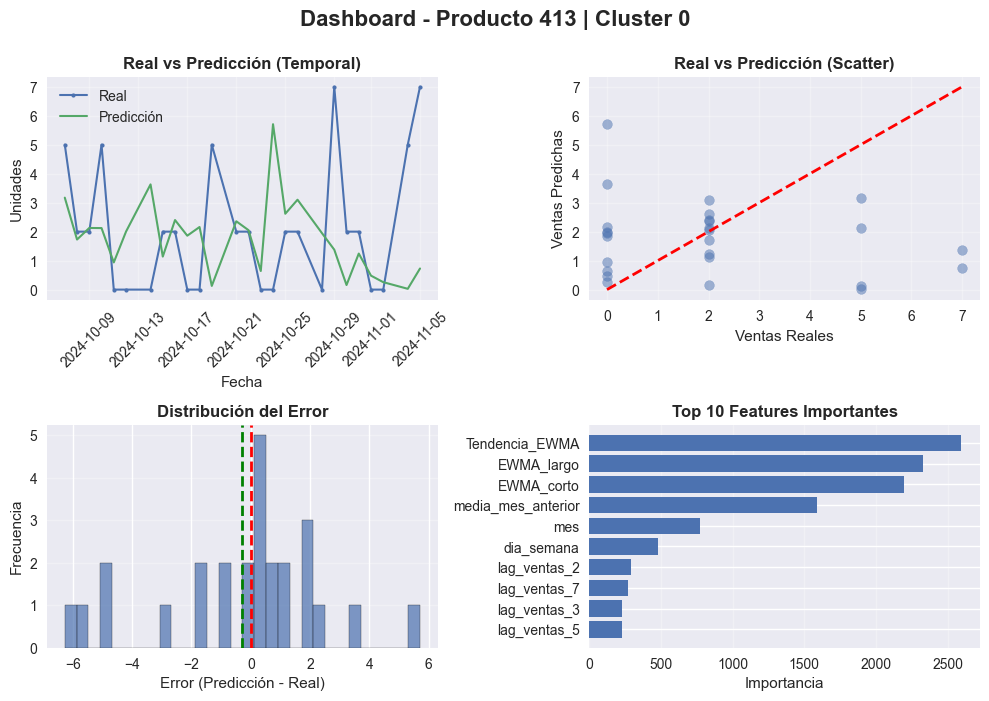


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 294 (C0) 2.9861 13.9095 3.7295 -0.7439     78.37     143.75 0.8592   161.75

🏆 Mejor modelo: LightGBM Producto 294 (C0) (RMSE: 3.7295)


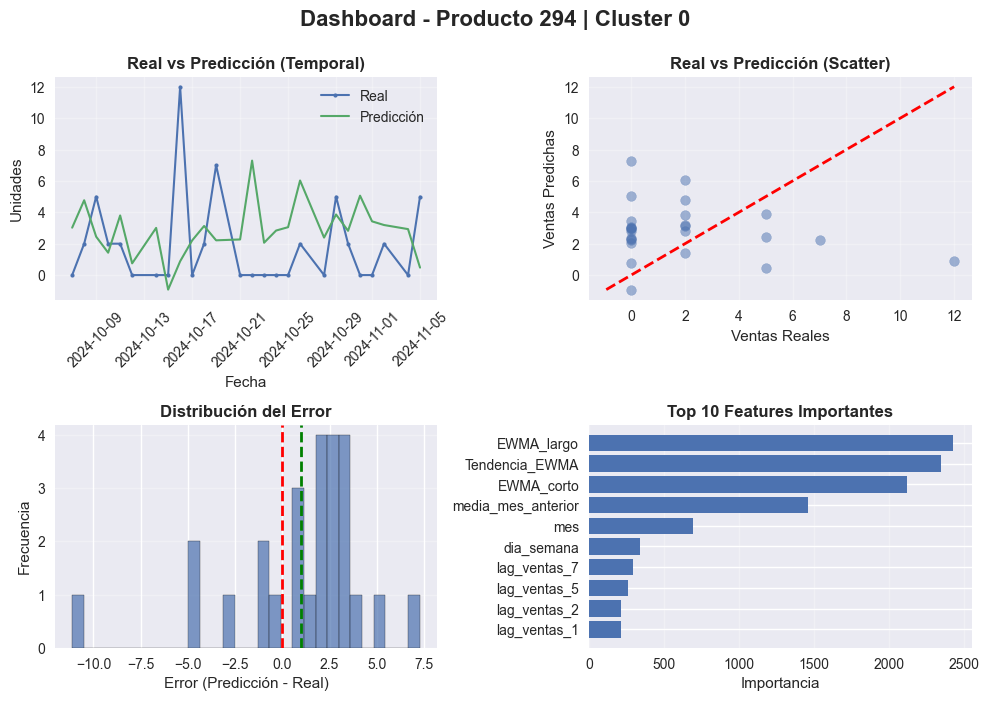


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 144 (C1) 4.1747 28.8138 5.3678 -0.1217     84.37      87.57 0.8023    73.84

🏆 Mejor modelo: LightGBM Producto 144 (C1) (RMSE: 5.3678)


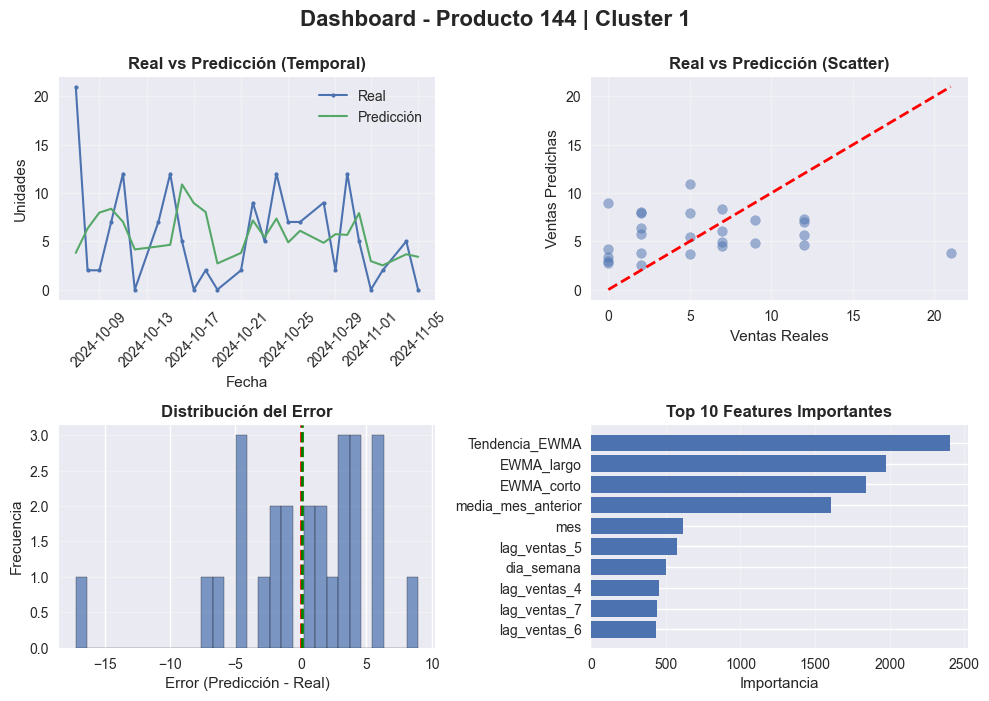


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
                Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 41 (C1) 4.0562 26.8868 5.1852 -0.3186     70.79      78.83 0.8851    61.31

🏆 Mejor modelo: LightGBM Producto 41 (C1) (RMSE: 5.1852)


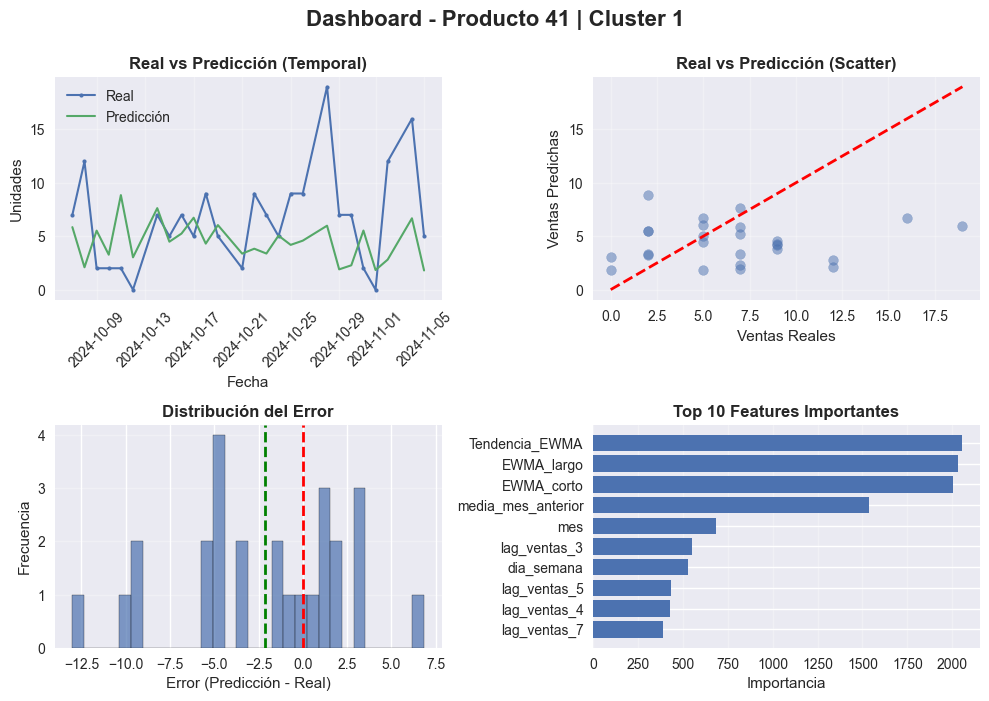


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
               Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 1 (C2) 8.0096 141.0939 11.8783 -0.1371    104.61      69.18 0.7478    67.83

🏆 Mejor modelo: LightGBM Producto 1 (C2) (RMSE: 11.8783)


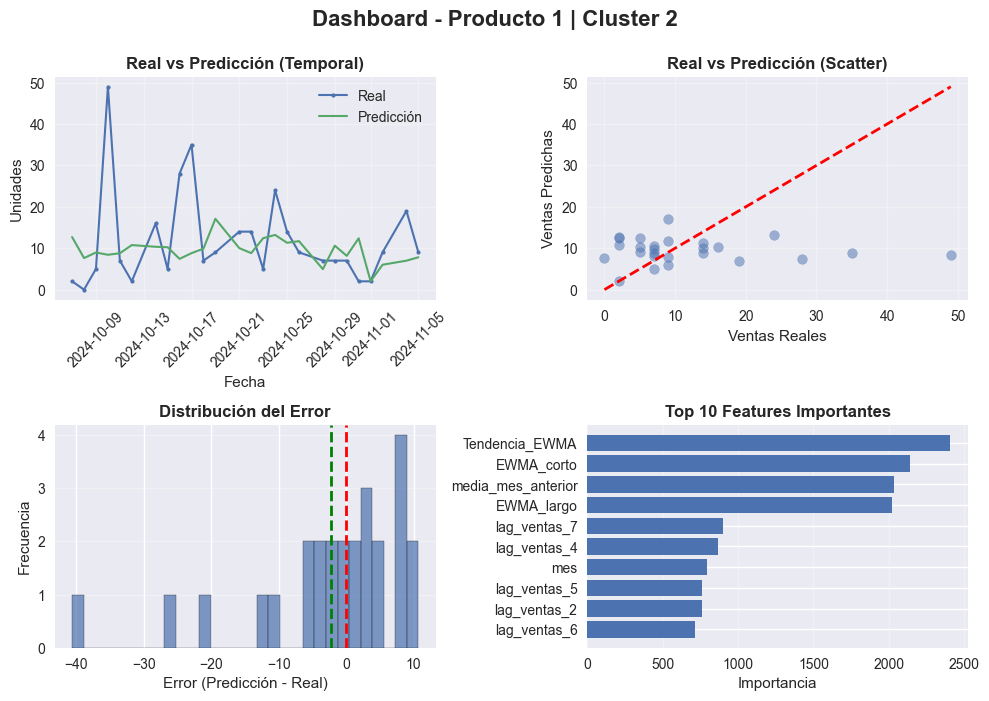


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
               Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 2 (C2) 4.2008 27.0364 5.1997 -0.3225     90.94      74.11 0.7225     66.6

🏆 Mejor modelo: LightGBM Producto 2 (C2) (RMSE: 5.1997)


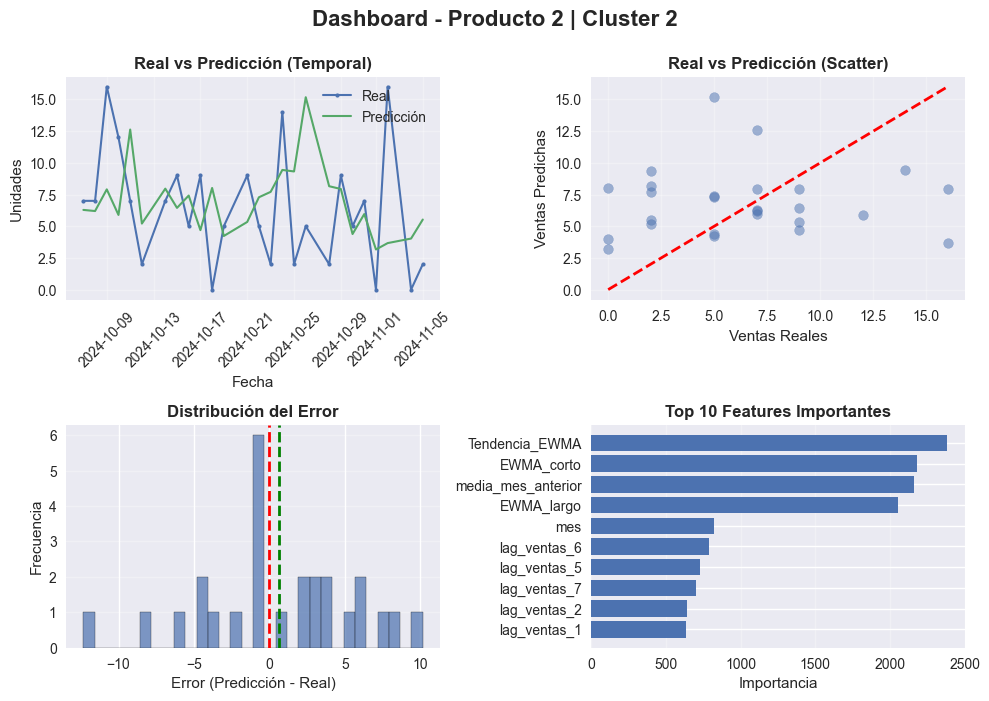


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 257 (C3) 1.2521 2.2899 1.5132 -0.7257     63.26     182.47 1.0296   250.43

🏆 Mejor modelo: LightGBM Producto 257 (C3) (RMSE: 1.5132)


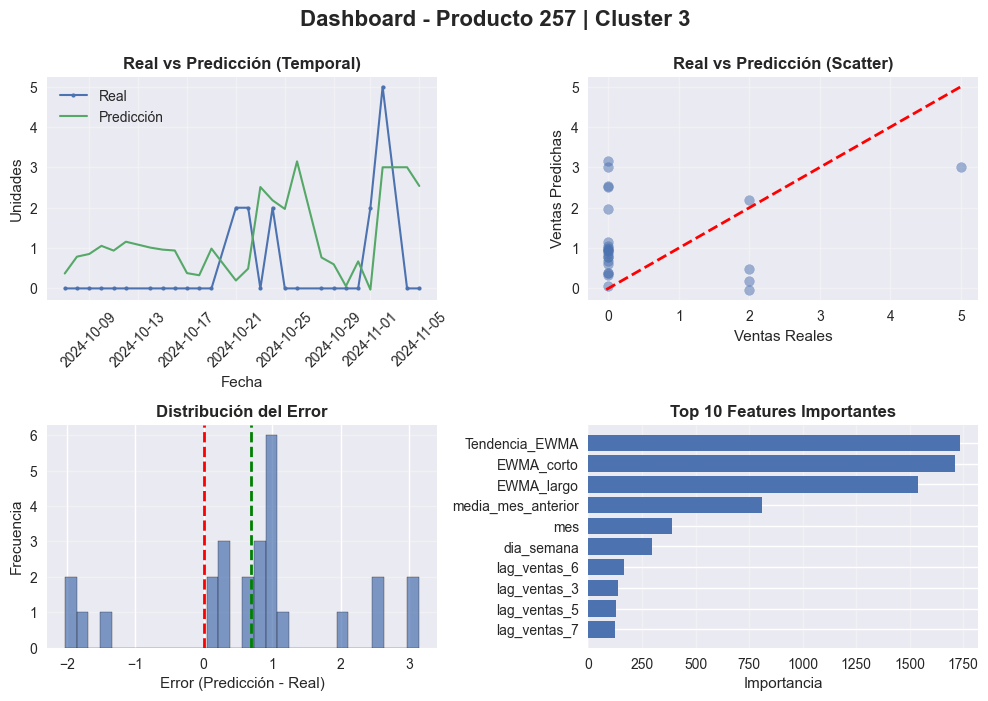


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE    MSE  RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 314 (C3) 0.1392 0.0372 0.193 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: LightGBM Producto 314 (C3) (RMSE: 0.1930)


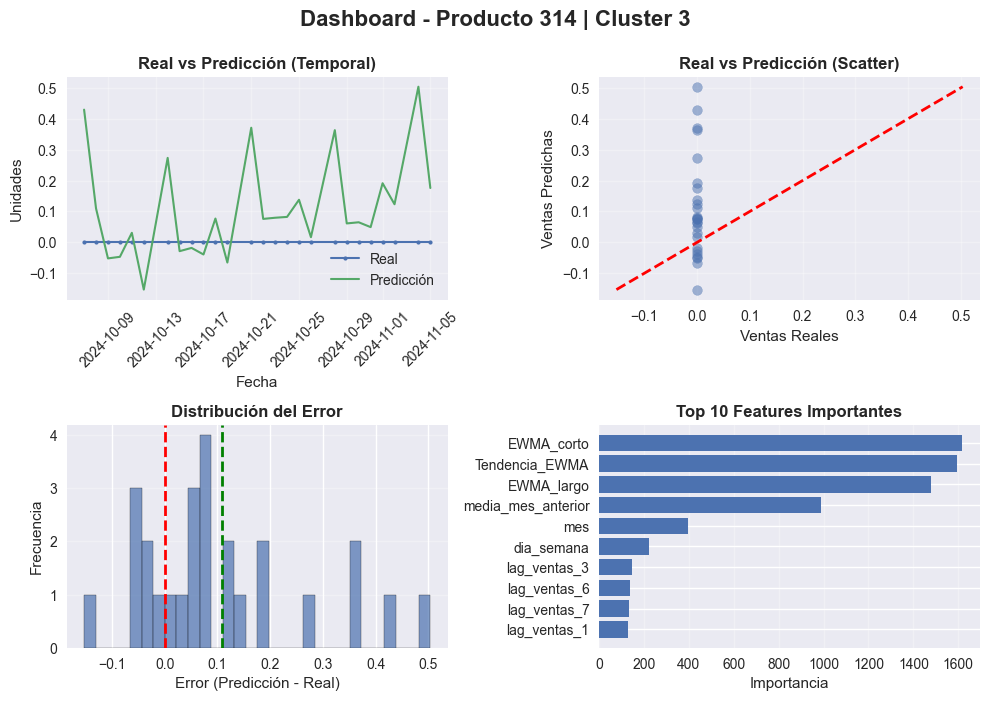


✅ Modelos por producto completados: 8 modelos entrenados


In [16]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: LIGHTGBM POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        lgb_producto = lgb.LGBMRegressor(
            **study_lgb.best_params,
            random_state=42,
            n_jobs=-1)
        
        lgb_producto.fit(X_train_p, y_train_p)
        y_pred_p = lgb_producto.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = lgb_producto
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(y_test_p, y_pred_p, f"LightGBM Producto {producto} (C{cluster})")
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=lgb_producto,
            feature_names=FEATURES,
            titulo_principal=f'Dashboard - Producto {producto} | Cluster {cluster}',
            figsize=(10, 7)
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas:

📊 RESUMEN DE MÉTRICAS
                             Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
            LightGBM Producto 314 (C3) 0.1392   0.0372  0.1930  0.0000       NaN     200.00    NaN      NaN
            LightGBM Producto 314 (C3) 0.1392   0.0372  0.1930  0.0000       NaN     200.00    NaN      NaN
       LightGBM Cluster 3 Producto 314 0.1356   0.0409  0.2023  0.0000       NaN     200.00    NaN      NaN
LightGBM Global Cluster 3 Producto 314 0.1936   0.0637  0.2523  0.0000       NaN     200.00    NaN      NaN
LightGBM Global Cluster 3 Producto 257 0.7872   1.3285  1.1526 -0.0012     76.26     185.97 0.7843   157.44
       LightGBM Cluster 3 Producto 257 0.9058   1.7545  1.3246 -0.3222     77.81     186.83 0.9013   181.17
            LightGBM Producto 257 (C3) 1.2521   2.2899  1.5132 -0.7257     63.26     182.47 1.0296   250.43
            LightGBM Produc

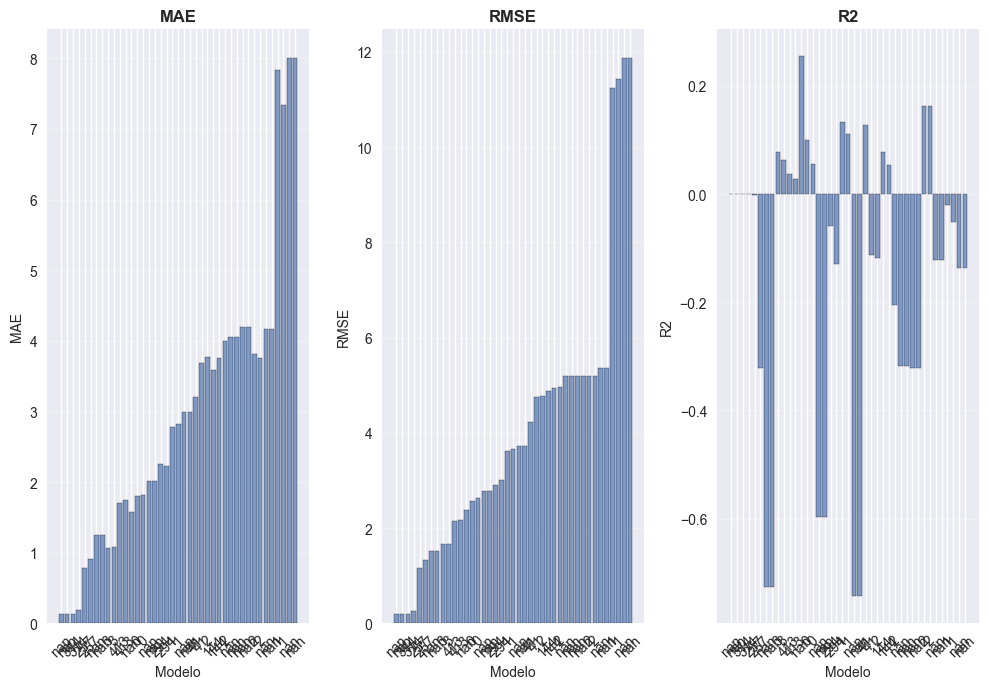


📊 ANÁLISIS POR CATEGORÍAS DE MODELOS

🌐 MODELOS GLOBALES:
                             Algoritmo    MAE    RMSE      R2
LightGBM Global Cluster 3 Producto 314 0.1936  0.2523  0.0000
LightGBM Global Cluster 3 Producto 257 0.7872  1.1526 -0.0012
             LightGBM Global Cluster 3 1.0734  1.6587  0.0781
LightGBM Global Cluster 0 Producto 413 1.7489  2.1699  0.0272
                       LightGBM Global 1.5698  2.3900  0.2546
             LightGBM Global Cluster 0 1.8023  2.5745  0.0996
LightGBM Global Cluster 0 Producto 294 2.2500  2.9077 -0.0600
             LightGBM Global Cluster 1 2.7862  3.6115  0.1325
 LightGBM Global Cluster 1 Producto 41 3.2112  4.2177  0.1276
LightGBM Global Cluster 1 Producto 144 3.5813  4.8696  0.0769
  LightGBM Global Cluster 2 Producto 2 3.9949  4.9630 -0.2048
             LightGBM Global Cluster 2 3.7518  5.2040  0.1631
  LightGBM Global Cluster 2 Producto 1 7.3373 11.4242 -0.0518

   Promedio RMSE: 3.65

🎯 MODELOS POR CLUSTER:
                         

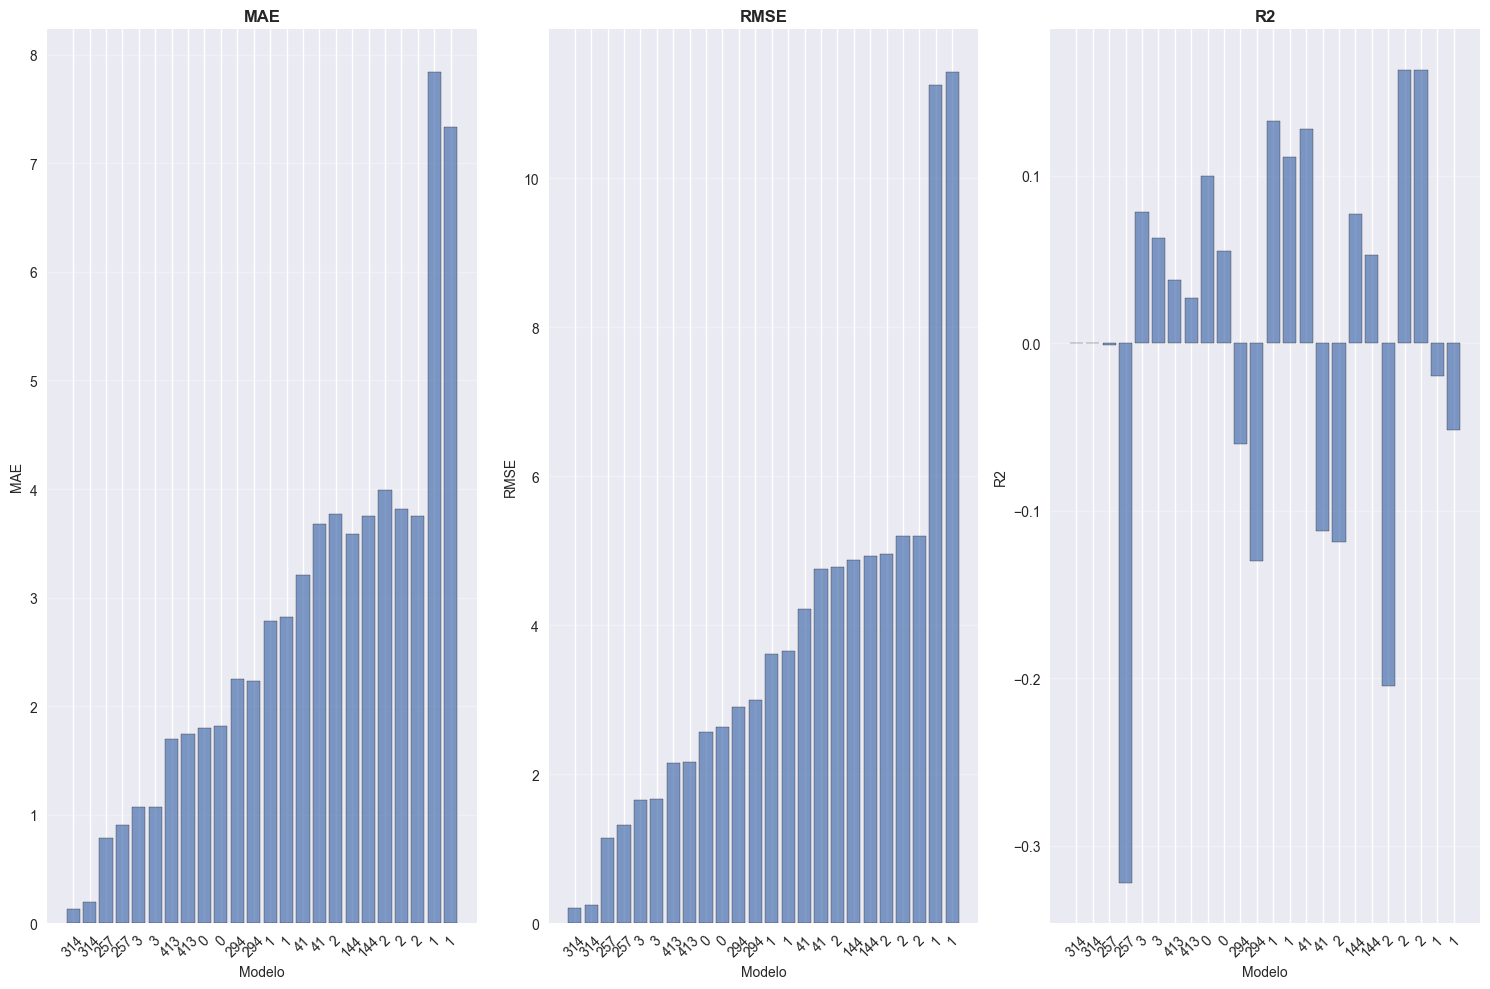


📊 Comparación entre productos:


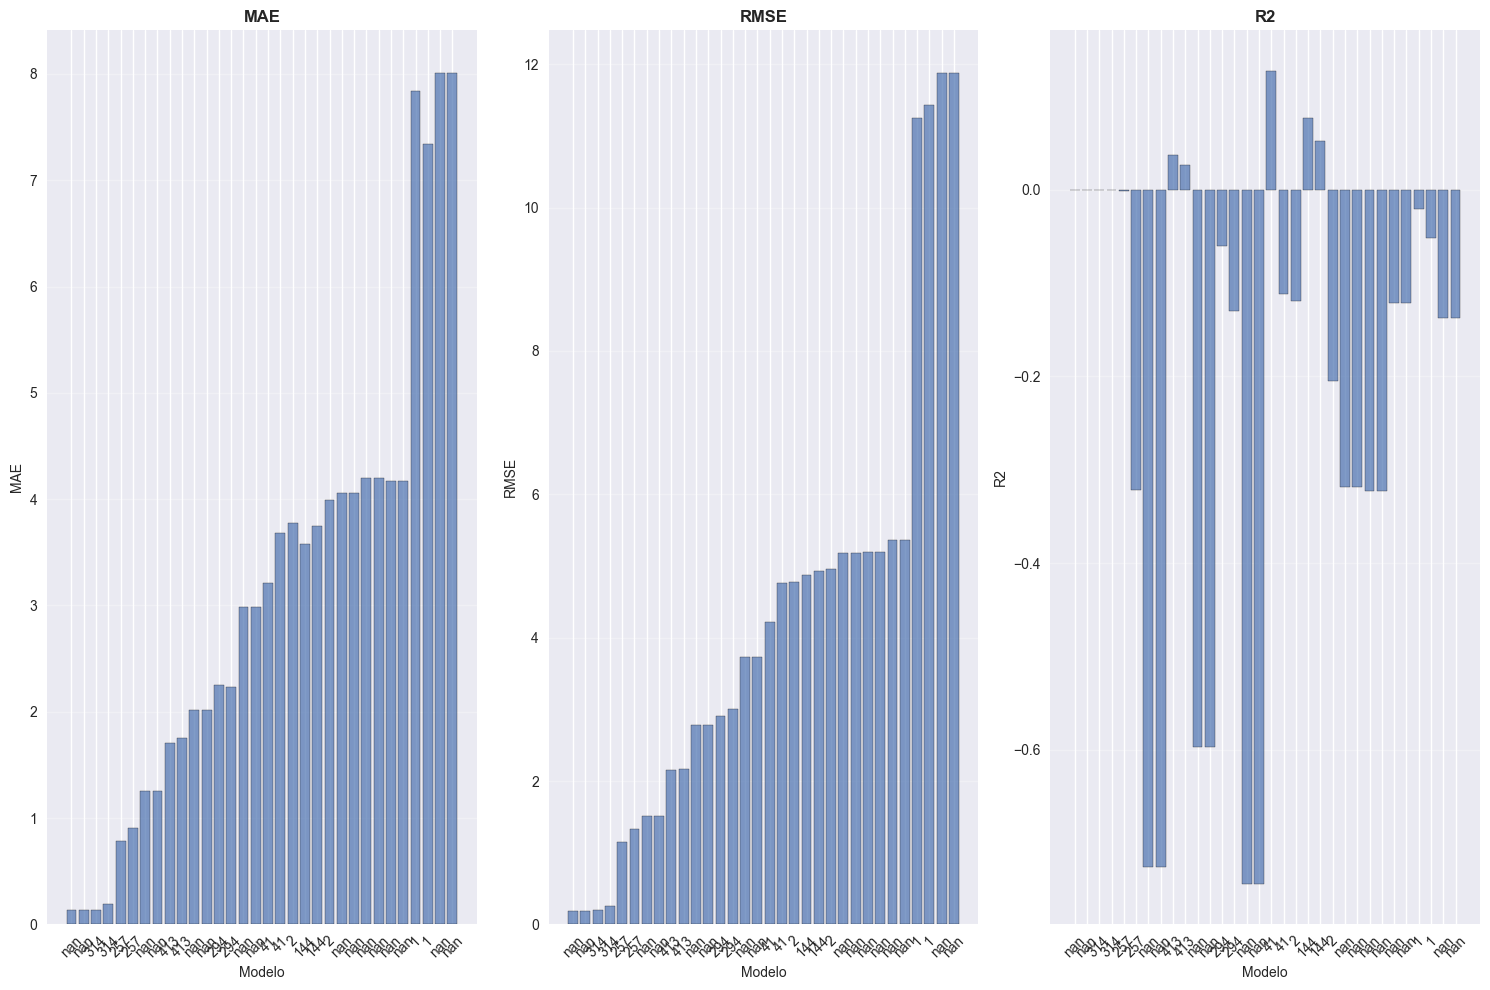


✅ ANÁLISIS COMPLETO FINALIZADO

📊 Total de modelos evaluados: 41
   - Modelos globales: 13
   - Modelos por cluster: 24
   - Modelos por producto: 32


In [19]:
# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Mostrar tabla completa de métricas
    print("\n📊 Resumen de todas las métricas:")
    resumen_metricas(todas_metricas)
    
    # Comparar métricas
    df_comparacion_final = comparar_metricas(todas_metricas, ordenar_por='RMSE')
    
    print("\n" + "="*100)
    print("📈 RANKING DE MODELOS POR RMSE")
    print("="*100)
    print(df_comparacion_final[['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)']].to_string(index=False))
    
    # Gráfico comparativo de TODOS los modelos
    print("\n📊 Generando gráficos comparativos...")
    grafico_comparacion_metricas(df_comparacion_final, metricas=['MAE', 'RMSE', 'R2'])
    
    # Análisis por categorías
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS")
    print("="*100)
    
    # Separar por tipo de modelo
    df_global = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Global')]
    df_clusters = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Cluster')]
    df_productos = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Producto')]
    
    print("\n🌐 MODELOS GLOBALES:")
    if len(df_global) > 0:
        print(df_global[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_global['RMSE'].mean():.2f}")
    
    print("\n🎯 MODELOS POR CLUSTER:")
    if len(df_clusters) > 0:
        print(df_clusters[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_clusters['RMSE'].mean():.2f}")
        print(f"   Mejor cluster: {df_clusters.iloc[0]['Algoritmo']} (RMSE: {df_clusters.iloc[0]['RMSE']:.2f})")
        print(f"   Peor cluster: {df_clusters.iloc[-1]['Algoritmo']} (RMSE: {df_clusters.iloc[-1]['RMSE']:.2f})")
    
    print("\n🛒 MODELOS POR PRODUCTO:")
    if len(df_productos) > 0:
        print(df_productos[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_productos['RMSE'].mean():.2f}")
        print(f"   Mejor producto: {df_productos.iloc[0]['Algoritmo']} (RMSE: {df_productos.iloc[0]['RMSE']:.2f})")
        print(f"   Peor producto: {df_productos.iloc[-1]['Algoritmo']} (RMSE: {df_productos.iloc[-1]['RMSE']:.2f})")
    
    # Mejor modelo general
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]
    
    print(f"\n🏆 {mejor_modelo['Algoritmo']}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    
    # Gráficos comparativos por categoría
    if len(df_clusters) > 1:
        print("\n📊 Comparación entre clusters:")
        grafico_comparacion_metricas(df_clusters, metricas=['MAE', 'RMSE', 'R2'], figsize=(15, 10))
    
    if len(df_productos) > 1:
        print("\n📊 Comparación entre productos:")
        grafico_comparacion_metricas(df_productos, metricas=['MAE', 'RMSE', 'R2'], figsize=(15, 10))
    
else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if 'Global' in m['Algoritmo']])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if 'Cluster' in m['Algoritmo']])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if 'Producto' in m['Algoritmo']])}")

# Salvar resultados

In [15]:
# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
# Guardar con un nombre distintivo para LightGBM
df_resultados.to_csv('datos/resultados_metricas_lightgbm.csv', index=False)
print("Resultados guardados en 'datos/resultados_metricas_lightgbm.csv'")

Resultados guardados en 'datos/resultados_metricas_lightgbm.csv'
